EDA PROCESS

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

df=pd.read_csv('product_catalog.csv')

In [3]:
df

,product_id,product_name,product_category,product_subcategory,brand,supplier,unit_price,product_cost,product_rating
0,PROD-000001,Apple Sharable bifurcated algorithm Smartphones,Electronics,Smartphones,Apple,Alibaba,686.90,474.06,4.3
1,PROD-000002,Google User-centric even-keeled encryption Sma...,Electronics,Smartphones,Google,Euro Logistics,978.26,519.66,2.9
2,PROD-000003,LG Face-to-face client-driven support Smartphones,Electronics,Smartphones,LG,Asian Manufacturing,275.51,185.48,3.9
3,PROD-000004,Sony Customer-focused systematic support Smart...,Electronics,Smartphones,Sony,Amazon Supply,1120.49,564.86,4.8
4,PROD-000005,OnePlus Quality-focused background parallelism...,Electronics,Smartphones,OnePlus,Direct Import,1282.18,695.54,2.9
...,...,...,...,...,...,...,...,...,...
1170,PROD-001171,Avery Inverse 4thgeneration productivity Calen...,Office Supplies,Calendars,Avery,Amazon Supply,107.23,33.97,4.8
1171,PROD-001172,Staples Future-proofed zero tolerance knowledg...,Office Supplies,Calendars,Staples,Pacific Trade,246.92,126.70,4.8
1172,PROD-001173,Mead Pre-emptive discrete help-desk Calendars,Office Supplies,Calendars,Mead,Alibaba,34.68,13.75,2.7
1173,PROD-001174,Avery Reactive homogeneous Internet solution C...,Office Supplies,Calendars,Avery,Asian Manufacturing,71.13,25.42,3.6


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1175 entries, 0 to 1174
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           1175 non-null   str    
 1   product_name         1175 non-null   str    
 2   product_category     1175 non-null   str    
 3   product_subcategory  1175 non-null   str    
 4   brand                1175 non-null   str    
 5   supplier             1175 non-null   str    
 6   unit_price           1175 non-null   float64
 7   product_cost         1175 non-null   float64
 8   product_rating       1175 non-null   float64
dtypes: float64(3), str(6)
memory usage: 207.5 KB


In [5]:
df.shape

(1175, 9)

In [6]:
df.isnull().sum()

product_id             0
product_name           0
product_category       0
product_subcategory    0
brand                  0
supplier               0
unit_price             0
product_cost           0
product_rating         0
dtype: int64

In [7]:
df.describe()

,unit_price,product_cost,product_rating
count,1175.000000,1175.000000,1175.000000
mean,245.524400,126.536826,3.683064
std,251.267683,150.131833,0.698046
min,6.310000,1.970000,2.500000
25%,74.710000,29.565000,3.100000
50%,165.420000,74.540000,3.700000
75%,311.295000,153.045000,4.300000
max,1482.950000,993.630000,4.900000


In [8]:
cat_vari=['product_id','product_name','product_category','product_subcategory','brand','supplier']
for var in cat_vari:
    af=df.value_counts(var)
    print(af)

product_id
PROD-000001    1
PROD-000002    1
PROD-000003    1
PROD-000004    1
PROD-000005    1
              ..
PROD-001171    1
PROD-001172    1
PROD-001173    1
PROD-001174    1
PROD-001175    1
Name: count, Length: 1175, dtype: int64
product_name
Apple Sharable bifurcated algorithm Smartphones                   1
Google User-centric even-keeled encryption Smartphones            1
LG Face-to-face client-driven support Smartphones                 1
Sony Customer-focused systematic support Smartphones              1
OnePlus Quality-focused background parallelism Smartphones        1
                                                                 ..
Avery Inverse 4thgeneration productivity Calendars                1
Staples Future-proofed zero tolerance knowledge user Calendars    1
Mead Pre-emptive discrete help-desk Calendars                     1
Avery Reactive homogeneous Internet solution Calendars            1
Office Depot Enterprise-wide systemic paradigm Calendars          1
N

In [9]:
df.duplicated().sum()

np.int64(0)

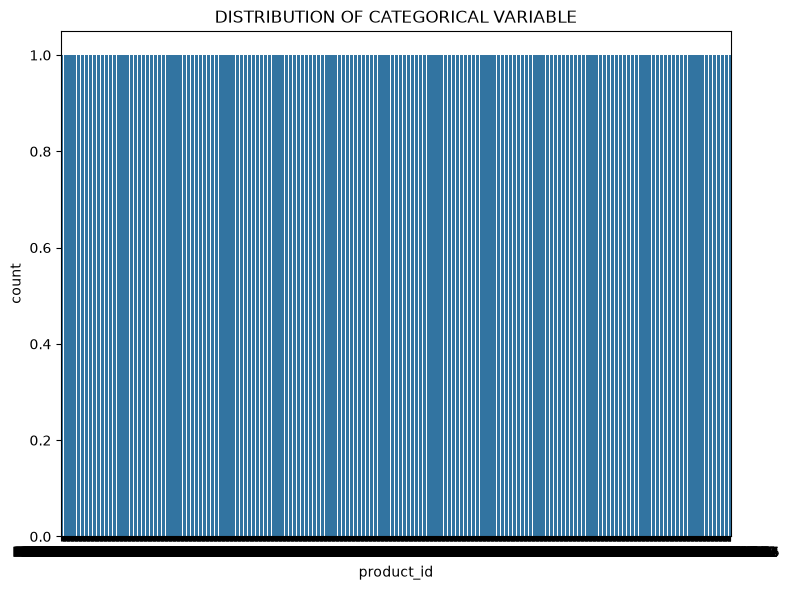

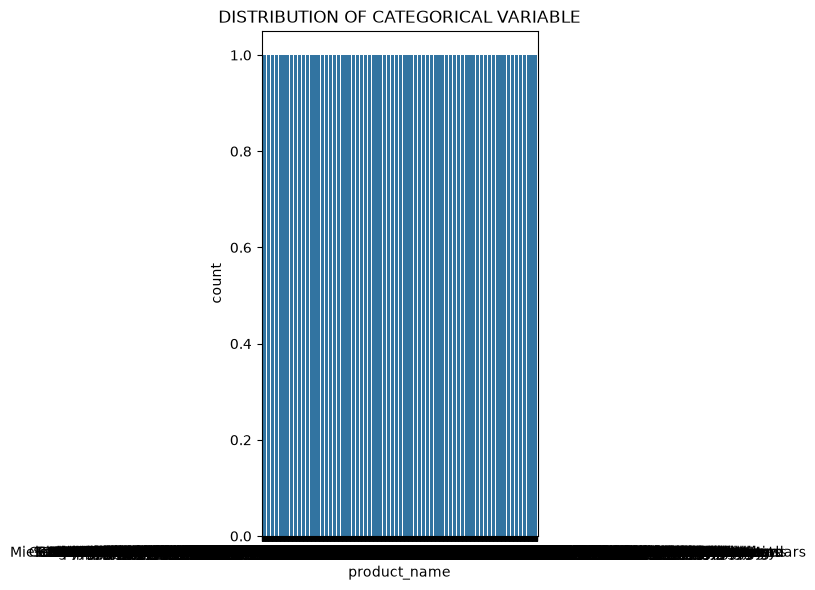

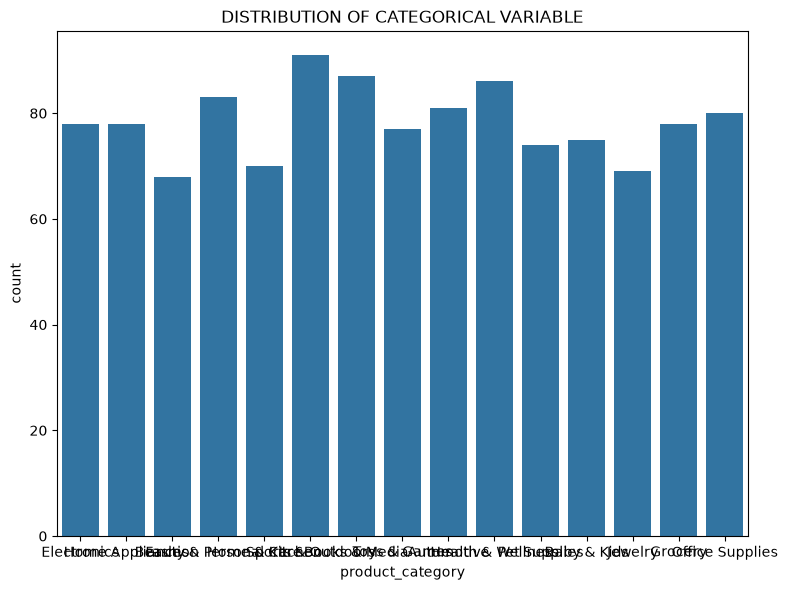

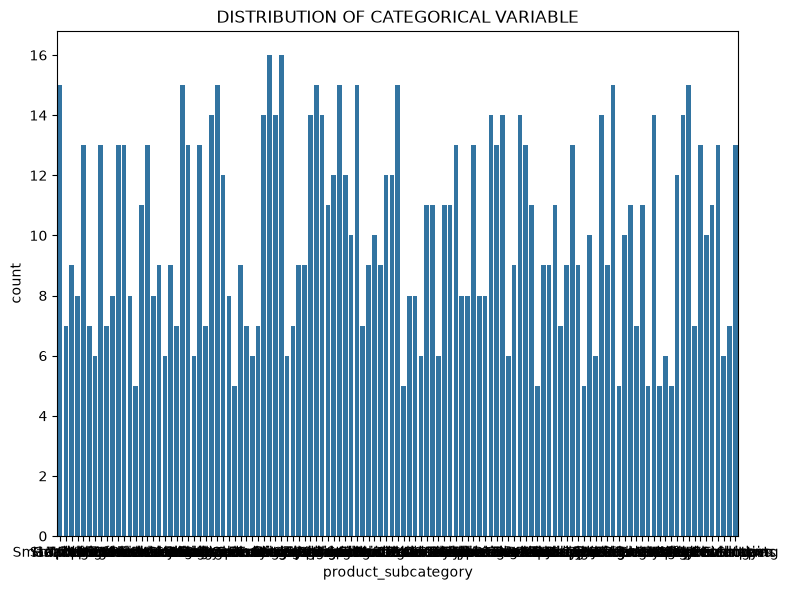

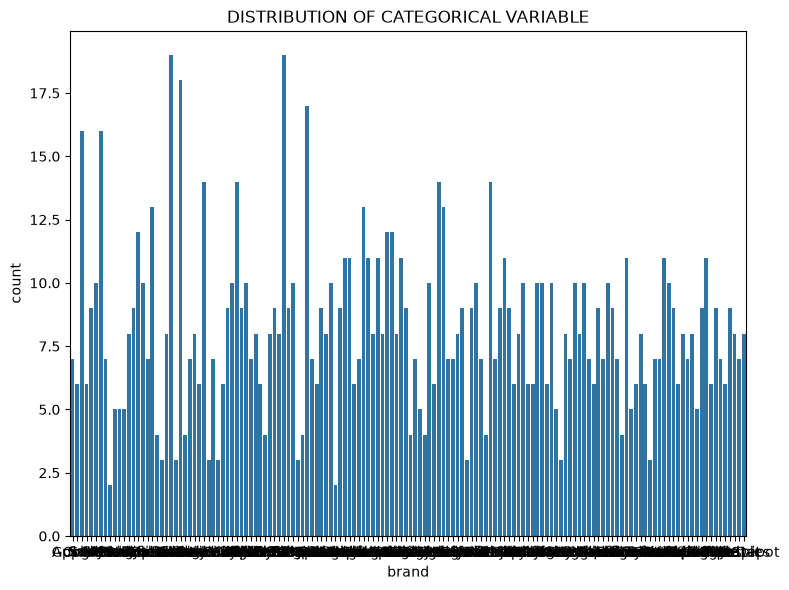

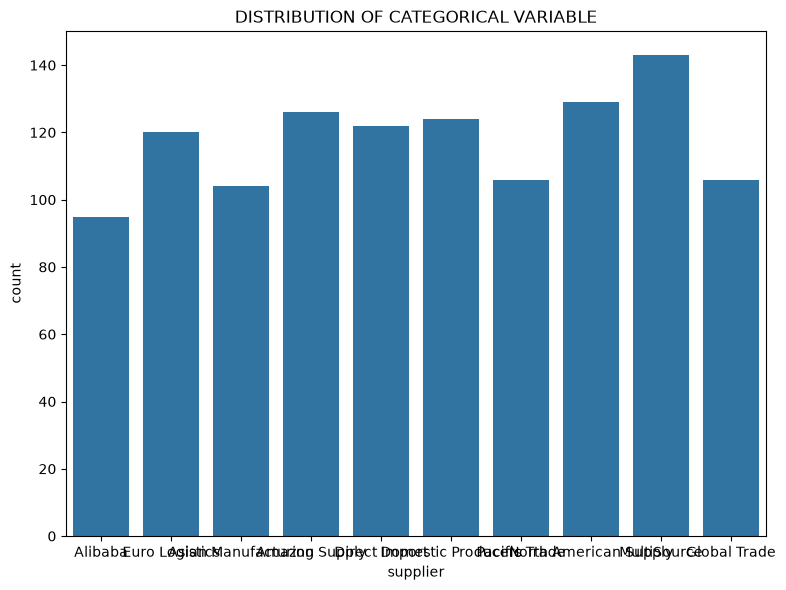

In [10]:

for col in cat_vari:
    plt.figure(figsize=(8,6))
    plt.title("DISTRIBUTION OF CATEGORICAL VARIABLE")
    sns.countplot(x=df[col])
    plt.tight_layout()

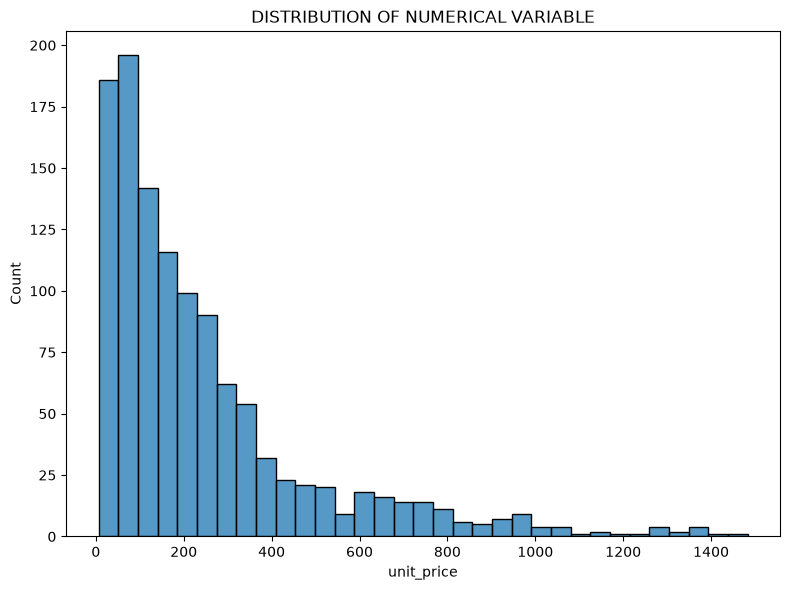

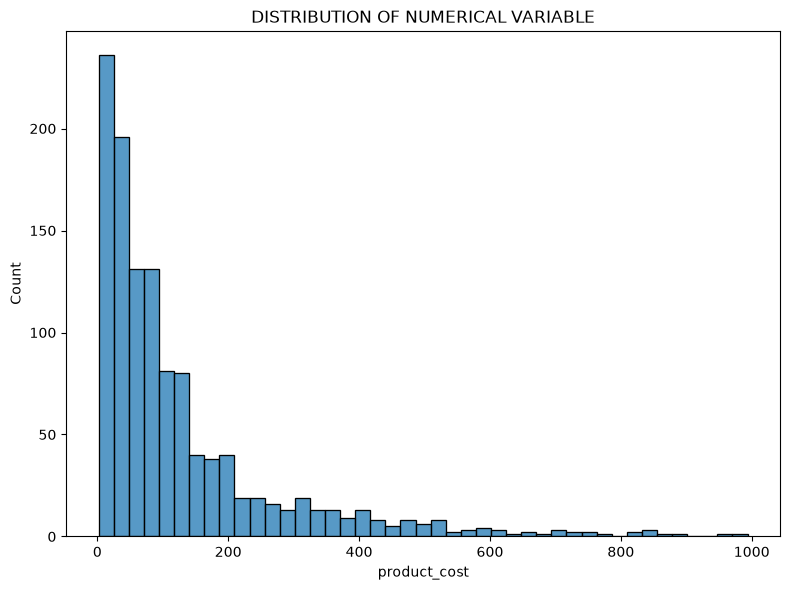

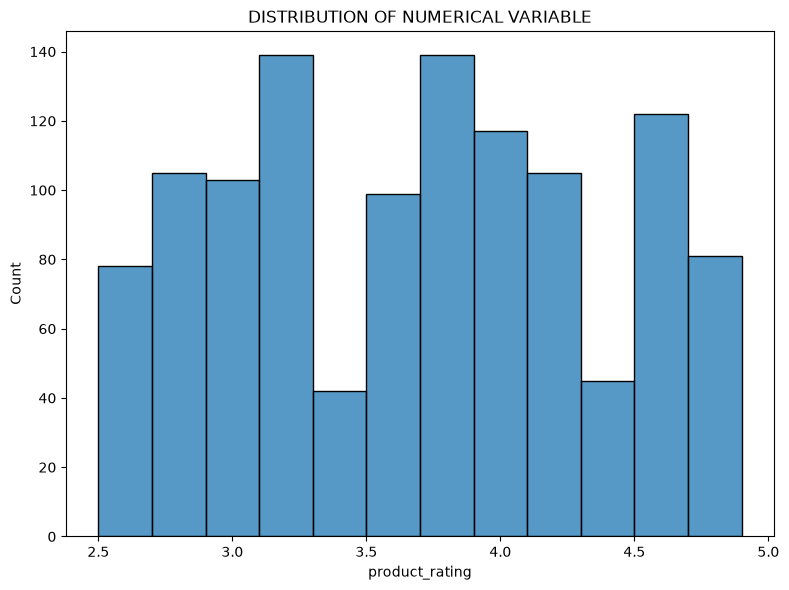

In [11]:
num_f=['unit_price','product_cost','product_rating']
for col in num_f:
   plt.figure(figsize=(8,6))
   plt.title("DISTRIBUTION OF NUMERICAL VARIABLE")
   sns.histplot(x=df[col])
   plt.tight_layout()


<Axes: ylabel='unit_price'>

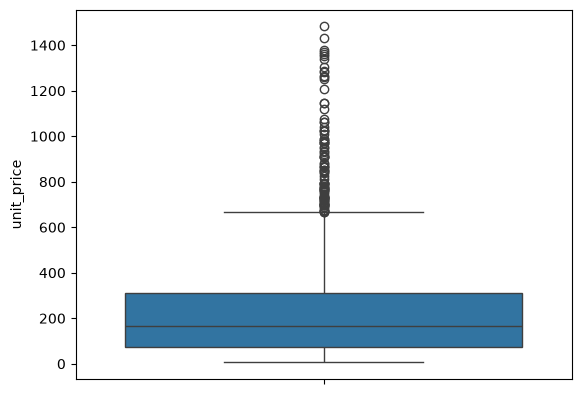

In [12]:
sns.boxplot(df['unit_price'])

<Axes: ylabel='product_rating'>

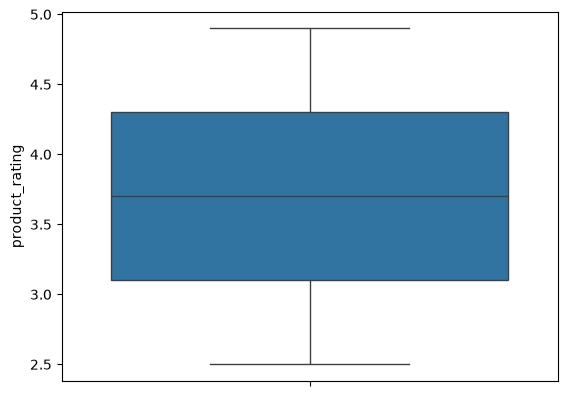

In [13]:
sns.boxplot(df['product_rating'])

<Axes: ylabel='product_cost'>

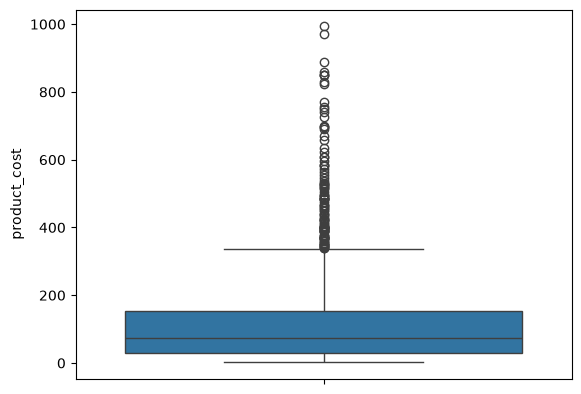

In [14]:
sns.boxplot(df['product_cost'])

In [15]:
q1=df['product_cost'].quantile(0.25)
q3=df['product_cost'].quantile(0.75)
iqr=q3-q1
iqr

np.float64(123.48000000000002)

In [16]:
df=df[(df['product_cost']>=q1-1.5*iqr)&(df['product_cost']<=q3+1.5*iqr)]

<Axes: ylabel='product_cost'>

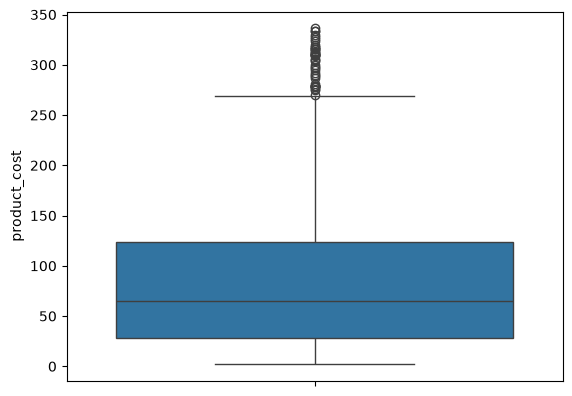

In [17]:
sns.boxplot(df['product_cost'])

In [18]:
q1=df['unit_price'].quantile(0.25)
q3=df['unit_price'].quantile(0.75)
iqr=q3-q1
iqr

np.float64(190.62)

In [19]:
df=df[(df['unit_price']>=q1-1.5*iqr)&(df['unit_price']<=q3+1.5*iqr)]

<Axes: ylabel='unit_price'>

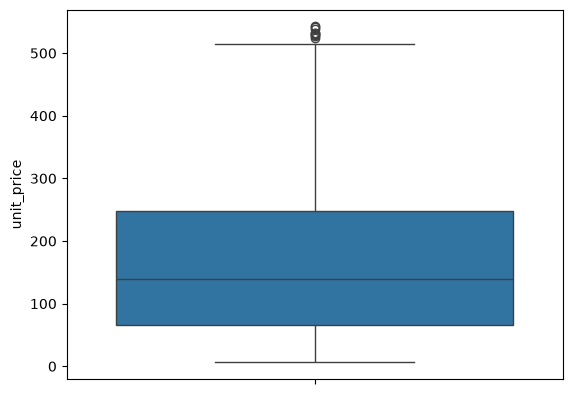

In [20]:
sns.boxplot(df['unit_price'])

In [21]:
df.value_counts('product_category')

product_category
Sports & Outdoors         91
Books & Media             87
Health & Wellness         86
Beauty & Personal Care    83
Office Supplies           80
Grocery                   78
Toys & Games              77
Baby & Kids               75
Pet Supplies              74
Automotive                73
Home & Kitchen            70
Fashion                   68
Home Appliances           42
Jewelry                   31
Electronics               22
Name: count, dtype: int64

<Axes: >

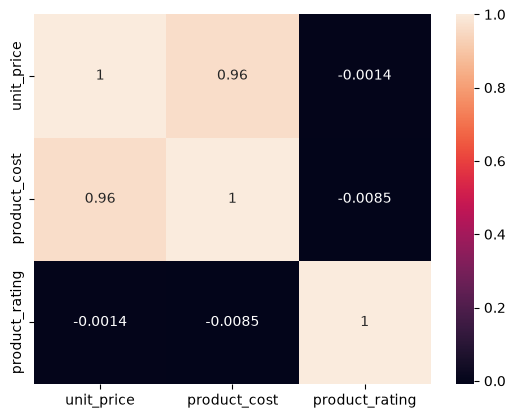

In [22]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [ ]:
from scipy.stats import chi2_contingency
alpha=0.05
chi2_results={}
for col in cat_vari:
    contigency=pd.crosstab(df[col],df['product_rating'])
    chi2_stat,p_val,_,_=chi2_contingency(contigency)
    decision='Reject Null (Keep Feature)' if p_val<alpha else 'Accept Null (Drop Feature)'
    chi2_results[col]={
        'chi2_statistics':chi2_stat,
        'p_value':p_val,
        'Decision':decision
    }
chi2_df=pd.DataFrame(chi2_results).T
chi2_df=chi2_df.sort_values(by='p_value')
chi2_df  